In [1]:
import time
t1 = time.time()

import scipy.special as sp
import scipy.stats as stats
import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-09-21 04:55:49.623686: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

HLdata_path = "/root/data/mucollider/two_boosted/3TeV/test_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/3TeV/test_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

BTag_leading = ((HLdata_file['BTag_leading'][:])&2)
BTag_subleading = ((HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': HLdata.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata.append(BTag_subleading)
    else: HLdata.append(HLdata_file[feature][:])
HLdata = np.array(HLdata).T
print('shape of high level data:', HLdata.shape)

LLdata = LLdata_file['particle_info'][:]
print('shape of low level data:', LLdata.shape)

target = HLdata_file['target_sigbg'][:]
print('shape of target:', target.shape)

shape of high level data: (347538, 16)
shape of low level data: (347538, 160)
shape of target: (347538,)


In [4]:
##### include data without TDA #####

HLfeatures_woTDA = ['BTag_leading', 'BTag_subleading', 'M_JJ', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures_woTDA = ['particle_info']

##### include other high level features data #####

HLdata_woTDA = []
for feature in HLfeatures_woTDA:
    if feature=='BTag_leading': HLdata_woTDA.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata_woTDA.append(BTag_subleading)
    else: HLdata_woTDA.append(HLdata_file[feature][:])
HLdata_woTDA = np.array(HLdata_woTDA).T
print('shape of high level data without TDA:', HLdata_woTDA.shape)

LLdata_woTDA = LLdata_file['particle_info'][:]
print('shape of low level data without TDA:', LLdata_woTDA.shape)

shape of high level data without TDA: (347538, 11)
shape of low level data without TDA: (347538, 160)


In [5]:
##### load the model #####

model = models.load_model("/root/data/mucollider/two_boosted/3TeV/ML_model/model_mucollider_10.h5")
model_woTDA = models.load_model("/root/data/mucollider/two_boosted/3TeV/ML_model/model_mucollider_woTDA.h5")

2026-09-21 04:55:52.097090: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


In [6]:
### model test ###

HLtest = []
LLtest = []
HLtest_woTDA = []
LLtest_woTDA = []
targettest = []
prediction = []
prediction_woTDA = []

BR_hbb = 0.5824
BR_Zqq = 0.69911
processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_num = [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Xsection = [5.6572451e-02*BR_hbb*BR_hbb, 4.758146e-03*BR_hbb*BR_hbb, 1.345440e+01, 4.423700e+00, 2.325600e+00, 1.507183e+02, 1.223107e+01, 9.617100e+00, 6.469436e+00, 1.27619546e+00*BR_hbb*BR_Zqq]     ### unit: fb
simulation_num = 200000
Luminosity = 1000   ### unit: fb^-1

count = 0
for process in processes:
    HLtest.append(HLdata[count:count+event_num[processes.index(process)]])
    LLtest.append(LLdata[count:count+event_num[processes.index(process)]])
    HLtest_woTDA.append(HLdata_woTDA[count:count+event_num[processes.index(process)]])
    LLtest_woTDA.append(LLdata_woTDA[count:count+event_num[processes.index(process)]])
    targettest.append(target[count:count+event_num[processes.index(process)]])
    prediction.append(model.predict([HLtest[-1], LLtest[-1]]))
    prediction_woTDA.append(model_woTDA.predict([HLtest_woTDA[-1], LLtest_woTDA[-1]]))
    count += event_num[processes.index(process)]

  88/1852 [>.............................] - ETA: 3s

2026-09-21 04:55:54.016976: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1665/1665 [==============================] - 3s 2ms/step


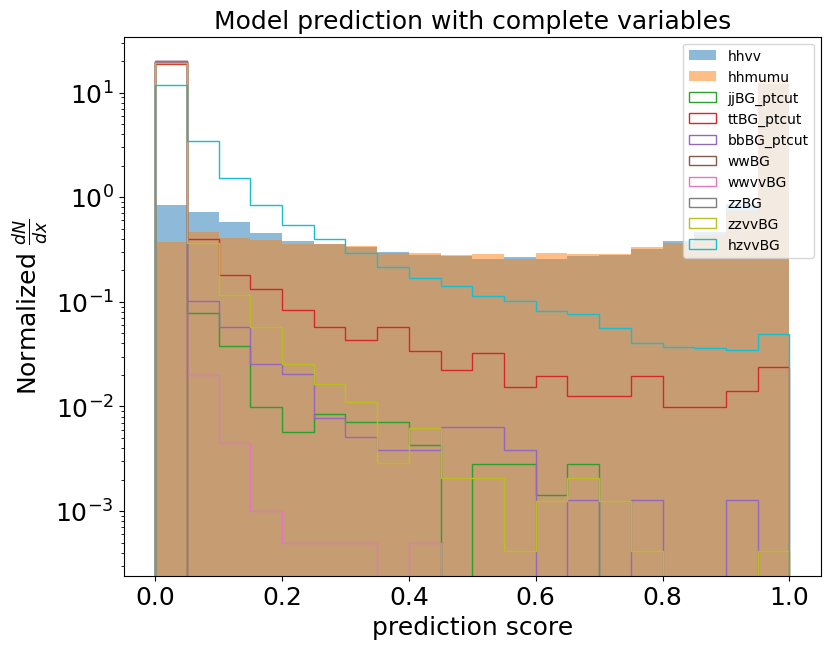

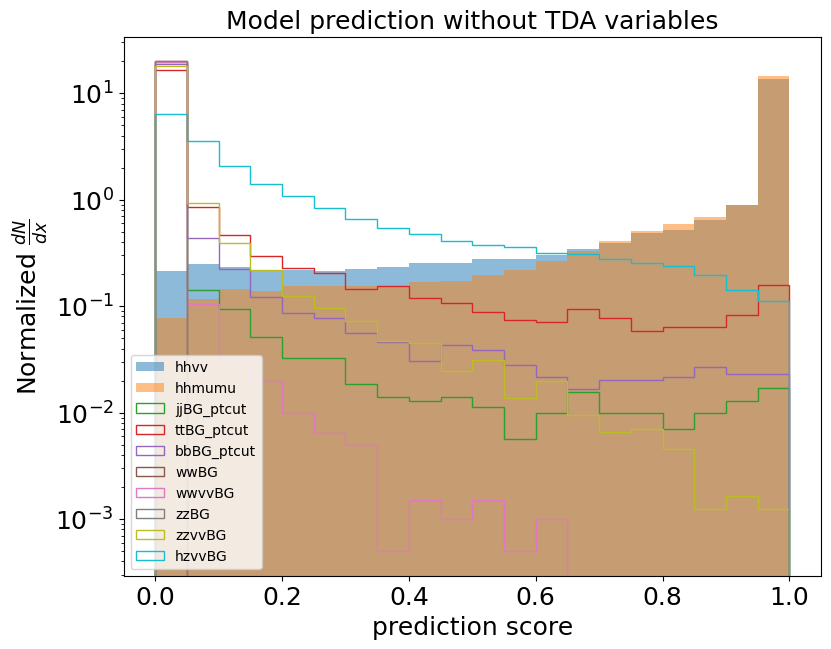

In [7]:
##### plot the prediction histogram #####

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.yscale("log")
plt.title("Model prediction with complete variables", fontsize=18)
plt.legend(loc='best')
plt.show()

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction_woTDA[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.yscale("log")
plt.title("Model prediction without TDA variables", fontsize=18)
plt.legend(loc='best')
plt.show()

In [8]:
### Do the score cut ###

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

def significance_smallN(s, b):
    if s==0: return 0
    n_obs = s + b
    exact_p_value = sp.gammainc(n_obs, b)
    exact_z_score = stats.norm.isf(exact_p_value)
    if exact_z_score<0: return 0
    else: return exact_z_score

score_cuts = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]

print("model prediction with complete variables:")
for score_cut in score_cuts:
    print("In score cut", score_cut)

    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score_cut)[0])
    print("Number before ML: ", event_num)
    print("Number after  ML: ", num_afterML)
    
    ### calculate significance ###
    
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z = significance_smallN(s,b)
    print("signal events:", s)
    print("background events:", b)
    print("significance:", z)
    print("\n")

print("model prediction without TDA variables:")
for score_cut in score_cuts:
    print("In score cut", score_cut)

    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction_woTDA[processes.index(process)]>=score_cut)[0])
    print("Number before ML: ", event_num)
    print("Number after  ML: ", num_afterML)
    
    ### calculate significance ###
    
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z = significance_smallN(s,b)
    print("signal events:", s)
    print("background events:", b)
    print("significance:", z)
    print("\n")

model prediction with complete variables:
In score cut 0.5
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [45816, 47536, 7, 121, 11, 0, 0, 0, 19, 1668]
signal events: 4.779364579929177
background events: 8.223359931470931
significance: 1.4392798783369507


In score cut 0.7
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [42682, 44267, 0, 64, 2, 0, 0, 0, 5, 673]
signal events: 4.452296714533373
background events: 3.349090022733775
significance: 1.9444661848686124


In score cut 0.8
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [40909, 42466, 0, 41, 1, 0, 0, 0, 1, 417]
signal events: 4.26765473813803
background events: 2.0342369328677328
significance: 2.2480414172656094


In score cut 0.9
Number before ML:  [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Number after  ML:  [38395, 4

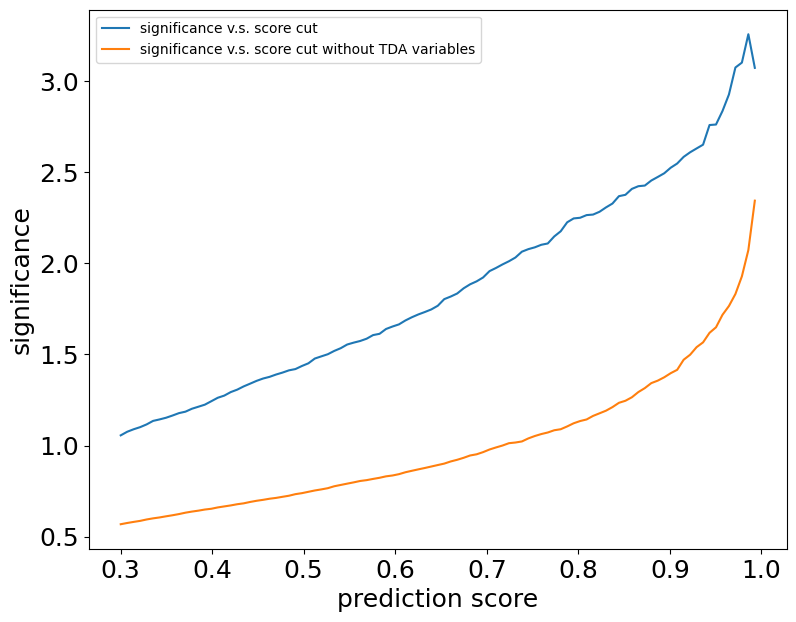

In [9]:
scores = np.linspace(0.3, 1, 100)
z_line = []
z_line_woTDA = []

for score in scores:
    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score)[0])
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z_line.append(significance_smallN(s,b))

for score in scores:
    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction_woTDA[processes.index(process)]>=score)[0])
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z_line_woTDA.append(significance_smallN(s,b))

plt.figure(1, figsize=(9,7))
plt.plot(scores[:-1], z_line[:-1], label='significance v.s. score cut')
plt.plot(scores[:-1], z_line_woTDA[:-1], label='significance v.s. score cut without TDA variables')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.legend(loc='best')
plt.show()

In [10]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:144.8332(s)
